# Report / slide visualization figures

This notebook creates the requested report figures and saves PNG files to `report_figures/`.

Figures:
1. Exercise video count bars: 89 / 94 / 25
2. Quality distribution bars: high 71, mid 92, low 39, plus per-exercise distribution
3. Skeleton extraction example image
4. Per-exercise phase F1 bars: 0.82 / 0.51 / 0.40
5. Phase confusion matrix heatmap
6. Deadlift variability with validation deadlift count = 2
7. User vs expert joint-angle trajectory line plot
8. Phase F1 by config table/bar
9. Training/validation curves: loss and F1


In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    import cv2
except Exception:
    cv2 = None

try:
    from IPython.display import display
except Exception:
    display = print

ROOT = Path.cwd()
FIG_DIR = ROOT / "report_figures"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]

K = {
    "squat": "\uc2a4\ucffc\ud2b8",
    "benchpress": "\ubca4\uce58\ud504\ub808\uc2a4",
    "deadlift": "\ub370\ub4dc\ub9ac\ud504\ud2b8",
    "high": "\uc0c1",
    "mid": "\uc911",
    "low": "\ud558",
    "exercise": "\uc885\ubaa9",
    "video_count": "\uc601\uc0c1 \uc218",
    "video_count_by_exercise": "\uc885\ubaa9\ubcc4 \uc601\uc0c1 \uc218",
    "quality": "\ud488\uc9c8",
    "quality_total_dist": "\ud488\uc9c8 \ub4f1\uae09\ubcc4 \uc804\uccb4 \ubd84\ud3ec",
    "quality_by_exercise": "\uc885\ubaa9\ubcc4 \ud488\uc9c8 \ubd84\ud3ec",
    "count_suffix": "\uac1c",
    "skeleton_example": "\uc2a4\ucf08\ub808\ud1a4 \ucd94\ucd9c \uc608\uc2dc",
    "phase_f1_by_exercise": "\uc885\ubaa9\ubcc4 Phase F1",
    "ready": "\uc900\ube44",
    "down": "\ud558\uac15",
    "up": "\uc0c1\uc2b9",
    "ratio": "\ube44\uc728",
    "phase_cm": "Phase \ud63c\ub3d9\ud589\ub82c",
    "pred_phase": "\uc608\uce21 phase",
    "true_phase": "\uc815\ub2f5 phase",
    "dead_var": "\ub370\ub4dc\ub9ac\ud504\ud2b8 Phase F1 \ubcc0\ub3d9\uc131 (validation deadlift=2)",
    "mean": "\ud3c9\uade0",
    "expert": "\uc804\ubb38\uac00",
    "user": "\uc0ac\uc6a9\uc790",
    "angle_traj": "\uc0ac\uc6a9\uc790 vs \uc804\ubb38\uac00 \uad00\uc808\uac01 \uada4\uc801",
    "progress": "\uc815\uaddc\ud654\ub41c \ub3d9\uc791 \uc9c4\ud589\ub960",
    "joint_angle": "\uad00\uc808\uac01(deg)",
    "full": "\uc804\uccb4",
    "high_mid": "\uc0c1+\uc911",
    "per_ex_head_mlp": "\uc885\ubaa9\ubcc4 head MLP",
    "per_ex_head_lstm": "\uc885\ubaa9\ubcc4 head LSTM",
    "config_phase_f1": "Config\ubcc4 Phase F1 \ube44\uad50",
    "train_val_curve": "\ud559\uc2b5\u00b7\uac80\uc99d \uace1\uc120",
}

EXERCISE_KR = {"squat": K["squat"], "benchpress": K["benchpress"], "deadlift": K["deadlift"]}
QUALITY_ORDER = [K["high"], K["mid"], K["low"]]
QUALITY_COLORS = {K["high"]: "#4C78A8", K["mid"]: "#F58518", K["low"]: "#E45756"}
EXERCISE_COLORS = {"squat": "#4C78A8", "benchpress": "#72B7B2", "deadlift": "#F58518"}
PHASE_NAMES = ["ready", "down", "up"]
PHASE_KR = {"ready": K["ready"], "down": K["down"], "up": K["up"]}


def savefig(name: str):
    """Save current matplotlib figure into report_figures/."""
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"saved: {path}")
    return path


def annotate_bars(ax, fmt="{:.0f}", dy=0.01):
    """Write values on top of vertical bars."""
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * dy
    for patch in ax.patches:
        h = patch.get_height()
        if not np.isfinite(h):
            continue
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            h + offset,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=10,
        )

print("ROOT:", ROOT)
print("FIG_DIR:", FIG_DIR)


ROOT: C:\Users\kojy1\PycharmProjects\capstone
FIG_DIR: C:\Users\kojy1\PycharmProjects\capstone\report_figures


## 0. Summary data for figures

Edit only this cell when the report numbers change.


In [2]:
# 1) Dataset count by exercise.
exercise_counts = pd.DataFrame(
    {
        "exercise": ["squat", "benchpress", "deadlift"],
        "exercise_label": [EXERCISE_KR[x] for x in ["squat", "benchpress", "deadlift"]],
        "videos": [89, 94, 25],
    }
)

# 2) Quality distribution by exercise. Totals: high=71, mid=92, low=39.
quality_by_exercise = pd.DataFrame(
    [
        {"exercise": "squat", "quality": K["high"], "videos": 40},
        {"exercise": "squat", "quality": K["mid"], "videos": 33},
        {"exercise": "squat", "quality": K["low"], "videos": 14},
        {"exercise": "benchpress", "quality": K["high"], "videos": 23},
        {"exercise": "benchpress", "quality": K["mid"], "videos": 49},
        {"exercise": "benchpress", "quality": K["low"], "videos": 20},
        {"exercise": "deadlift", "quality": K["high"], "videos": 8},
        {"exercise": "deadlift", "quality": K["mid"], "videos": 10},
        {"exercise": "deadlift", "quality": K["low"], "videos": 5},
    ]
)
quality_by_exercise["exercise_label"] = quality_by_exercise["exercise"].map(EXERCISE_KR)
quality_totals = quality_by_exercise.groupby("quality", as_index=False)["videos"].sum()
quality_totals["quality"] = pd.Categorical(quality_totals["quality"], QUALITY_ORDER, ordered=True)
quality_totals = quality_totals.sort_values("quality")

# 3) Rounded per-exercise phase F1 for slide: squat / benchpress / deadlift.
phase_f1_by_exercise = pd.DataFrame(
    {
        "exercise": ["squat", "benchpress", "deadlift"],
        "exercise_label": [EXERCISE_KR[x] for x in ["squat", "benchpress", "deadlift"]],
        "phase_f1": [0.82, 0.51, 0.40],
    }
)

# 4) Config-level phase F1 values used in the comparison figure.
config_phase_f1 = pd.DataFrame(
    [
        {"config": "Full MediaPipe MLP", "subset": K["full"], "model": "MLP", "phase_f1": 0.654},
        {"config": "YOLO MLP", "subset": K["full"], "model": "MLP", "phase_f1": 0.587},
        {"config": f"{K['high']} MLP", "subset": K["high"], "model": "MLP", "phase_f1": 0.694},
        {"config": f"{K['high']} LSTM", "subset": K["high"], "model": "LSTM", "phase_f1": 0.715},
        {"config": f"{K['high_mid']} MLP", "subset": K["high_mid"], "model": "MLP", "phase_f1": 0.661},
        {"config": f"{K['high_mid']} LSTM", "subset": K["high_mid"], "model": "LSTM", "phase_f1": 0.645},
        {"config": K["per_ex_head_mlp"], "subset": K["high"], "model": "MLP", "phase_f1": 0.729},
        {"config": K["per_ex_head_lstm"], "subset": K["high"], "model": "LSTM", "phase_f1": 0.729},
    ]
)

# 5) Deadlift F1 variability examples. val=2 means deadlift validation examples are only two videos.
deadlift_variability = pd.DataFrame(
    [
        {"config": f"{K['high']} MLP", "deadlift_phase_f1": 0.194, "val_deadlift_videos": 2},
        {"config": f"{K['high']} LSTM", "deadlift_phase_f1": 0.378, "val_deadlift_videos": 2},
        {"config": f"{K['high_mid']} MLP", "deadlift_phase_f1": 0.455, "val_deadlift_videos": 2},
        {"config": f"{K['high_mid']} LSTM", "deadlift_phase_f1": 0.352, "val_deadlift_videos": 2},
        {"config": K["per_ex_head_mlp"], "deadlift_phase_f1": 0.556, "val_deadlift_videos": 2},
        {"config": K["per_ex_head_lstm"], "deadlift_phase_f1": 0.546, "val_deadlift_videos": 2},
    ]
)

print("exercise_counts")
display(exercise_counts)
print("quality_totals")
display(quality_totals)
print("quality_by_exercise")
display(quality_by_exercise)


exercise_counts


,exercise,exercise_label,videos
0,squat,스쿼트,89
1,benchpress,벤치프레스,94
2,deadlift,데드리프트,25


quality_totals


,quality,videos
0,상,71
1,중,92
2,하,39


quality_by_exercise


,exercise,quality,videos,exercise_label
0,squat,상,40,스쿼트
1,squat,중,33,스쿼트
2,squat,하,14,스쿼트
3,benchpress,상,23,벤치프레스
4,benchpress,중,49,벤치프레스
5,benchpress,하,20,벤치프레스
6,deadlift,상,8,데드리프트
7,deadlift,중,10,데드리프트
8,deadlift,하,5,데드리프트


## 1. Exercise video count bars


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\01_exercise_video_counts.png


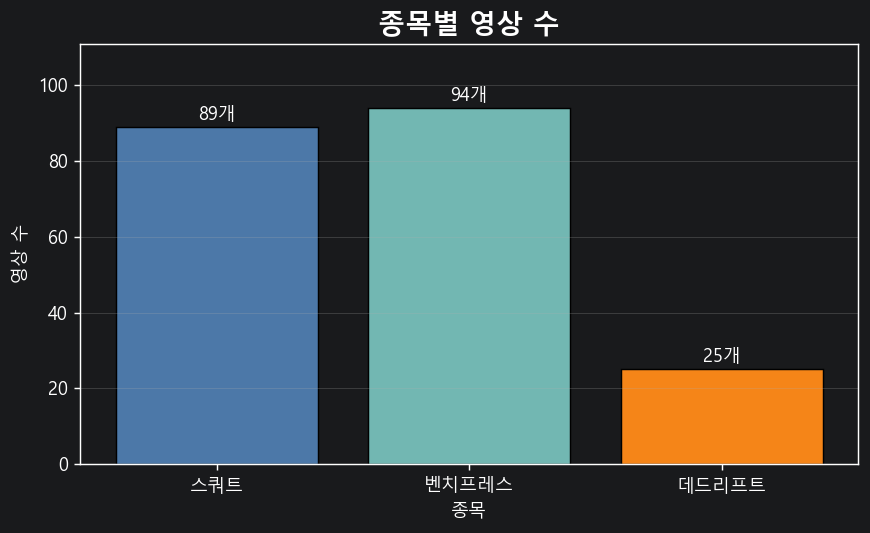

In [3]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
colors = [EXERCISE_COLORS[x] for x in exercise_counts["exercise"]]
ax.bar(exercise_counts["exercise_label"], exercise_counts["videos"], color=colors, edgecolor="black", linewidth=0.8)
ax.set_title(K["video_count_by_exercise"], fontsize=15, weight="bold")
ax.set_xlabel(K["exercise"])
ax.set_ylabel(K["video_count"])
ax.set_ylim(0, exercise_counts["videos"].max() * 1.18)
annotate_bars(ax, fmt="{:.0f}" + K["count_suffix"])
ax.grid(axis="y", alpha=0.25)
savefig("01_exercise_video_counts.png")
plt.show()


## 2. Quality distribution bars


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\02_quality_distribution.png


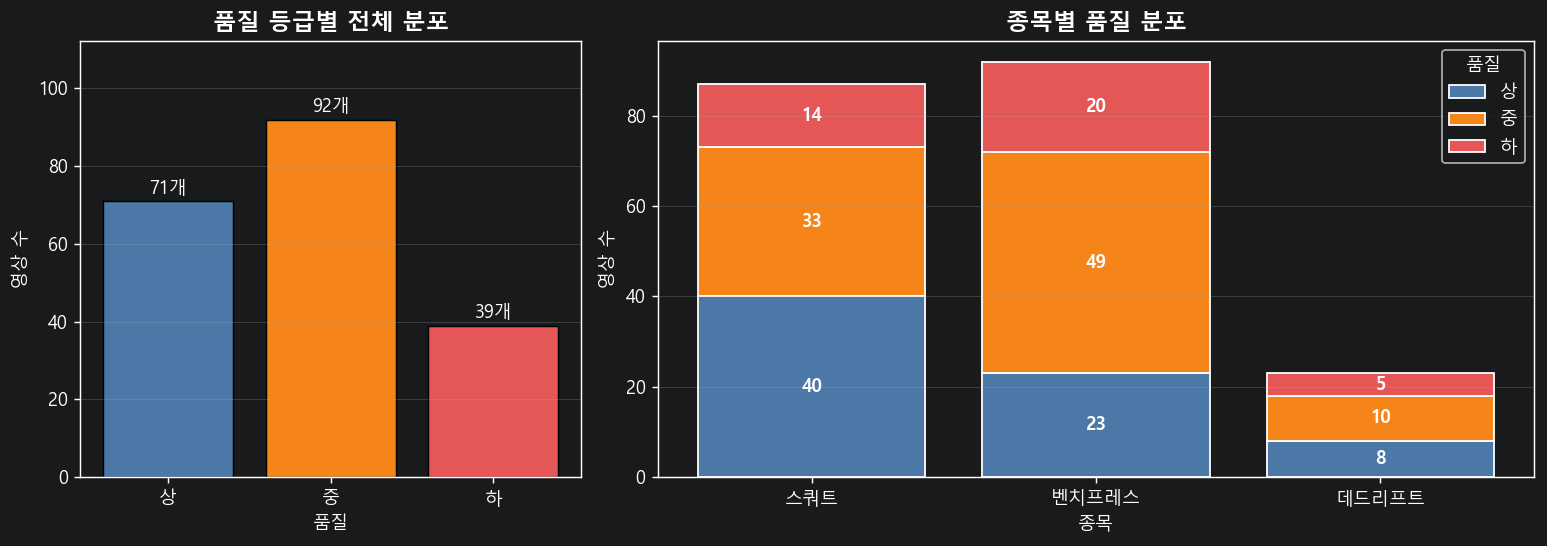

In [4]:
quality_pivot = (
    quality_by_exercise.pivot(index="exercise_label", columns="quality", values="videos")
    .reindex([EXERCISE_KR[x] for x in ["squat", "benchpress", "deadlift"]])
    .reindex(columns=QUALITY_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [0.8, 1.4]})

ax = axes[0]
ax.bar(
    quality_totals["quality"].astype(str),
    quality_totals["videos"],
    color=[QUALITY_COLORS[q] for q in quality_totals["quality"].astype(str)],
    edgecolor="black",
    linewidth=0.8,
)
ax.set_title(K["quality_total_dist"], fontsize=13, weight="bold")
ax.set_xlabel(K["quality"])
ax.set_ylabel(K["video_count"])
ax.set_ylim(0, quality_totals["videos"].max() * 1.22)
annotate_bars(ax, fmt="{:.0f}" + K["count_suffix"])
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
bottom = np.zeros(len(quality_pivot))
for q in QUALITY_ORDER:
    vals = quality_pivot[q].to_numpy()
    ax.bar(quality_pivot.index, vals, bottom=bottom, label=q, color=QUALITY_COLORS[q], edgecolor="white")
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(i, bottom[i] + v / 2, f"{int(v)}", ha="center", va="center", color="white", fontsize=10, weight="bold")
    bottom += vals
ax.set_title(K["quality_by_exercise"], fontsize=13, weight="bold")
ax.set_xlabel(K["exercise"])
ax.set_ylabel(K["video_count"])
ax.legend(title=K["quality"], frameon=True)
ax.grid(axis="y", alpha=0.25)

savefig("02_quality_distribution.png")
plt.show()


## 3. Skeleton extraction example

Default input: `infer/squat_15.mp4` and `infer/squat_15.json`.


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\03_skeleton_example.png


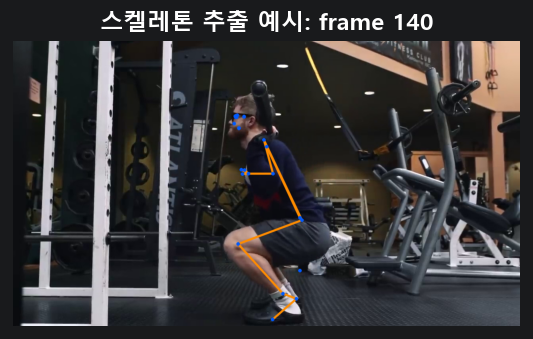

In [5]:
POSE_EDGES = [
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
    (11, 23), (12, 24), (23, 24),
    (23, 25), (25, 27), (27, 29), (29, 31),
    (24, 26), (26, 28), (28, 30), (30, 32),
    (15, 17), (15, 19), (15, 21),
    (16, 18), (16, 20), (16, 22),
]


def load_profile_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, dict) and "frames" in data:
        return data
    raise ValueError(f"Unsupported profile JSON structure: {path}")


def get_frame_by_idx(profile, frame_idx):
    frames = profile["frames"]
    by_idx = {int(fr.get("frame_idx", i)): fr for i, fr in enumerate(frames)}
    if frame_idx in by_idx:
        return by_idx[frame_idx]
    return frames[min(max(frame_idx, 0), len(frames) - 1)]


def read_video_frame(video_path, frame_idx):
    video_path = Path(video_path)
    if cv2 is None or not video_path.exists():
        return None
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def draw_pose_skeleton(image, landmarks, visibility_thr=0.35):
    if image is None:
        image = np.ones((720, 406, 3), dtype=np.uint8) * 255
    image = image.copy()
    h, w = image.shape[:2]

    def point(i):
        if i >= len(landmarks):
            return None
        lm = landmarks[i]
        if len(lm) >= 4 and lm[3] < visibility_thr:
            return None
        return int(lm[0] * w), int(lm[1] * h)

    if cv2 is not None:
        for a, b in POSE_EDGES:
            pa, pb = point(a), point(b)
            if pa is not None and pb is not None:
                cv2.line(image, pa, pb, (255, 140, 0), 3, lineType=cv2.LINE_AA)
        for i in range(len(landmarks)):
            p = point(i)
            if p is not None:
                cv2.circle(image, p, 4, (0, 90, 255), -1, lineType=cv2.LINE_AA)
    return image

# Change these two lines if you want another example.
SKELETON_VIDEO = ROOT / "infer" / "squat_15.mp4"
SKELETON_JSON = ROOT / "infer" / "squat_15.json"
SKELETON_FRAME_IDX = 140

if not SKELETON_JSON.exists():
    raise FileNotFoundError(f"Skeleton JSON not found: {SKELETON_JSON}")

profile = load_profile_json(SKELETON_JSON)
frame_data = get_frame_by_idx(profile, SKELETON_FRAME_IDX)
landmarks = frame_data["landmarks"]
frame_idx = int(frame_data.get("frame_idx", SKELETON_FRAME_IDX))
base_image = read_video_frame(SKELETON_VIDEO, frame_idx)
pose_image = draw_pose_skeleton(base_image, landmarks)

fig, ax = plt.subplots(figsize=(4.2, 6.5))
ax.imshow(pose_image)
ax.set_title(f"{K['skeleton_example']}: frame {frame_idx}", fontsize=13, weight="bold")
ax.axis("off")
savefig("03_skeleton_example.png")
plt.show()


## 4. Per-exercise phase F1 bars


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\04_phase_f1_by_exercise.png


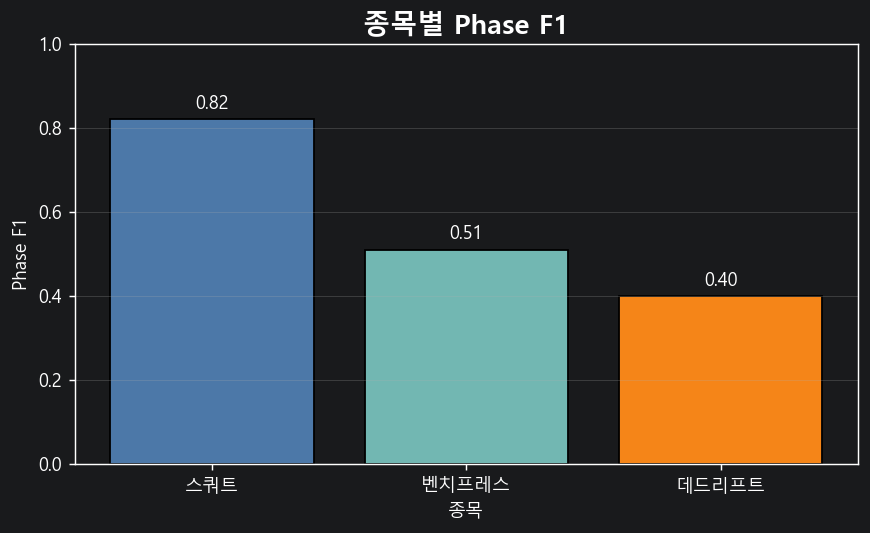

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
colors = [EXERCISE_COLORS[x] for x in phase_f1_by_exercise["exercise"]]
ax.bar(phase_f1_by_exercise["exercise_label"], phase_f1_by_exercise["phase_f1"], color=colors, edgecolor="black")
ax.set_title(K["phase_f1_by_exercise"], fontsize=15, weight="bold")
ax.set_xlabel(K["exercise"])
ax.set_ylabel("Phase F1")
ax.set_ylim(0, 1.0)
annotate_bars(ax, fmt="{:.2f}", dy=0.015)
ax.grid(axis="y", alpha=0.25)
savefig("04_phase_f1_by_exercise.png")
plt.show()


## 5. Phase confusion matrix heatmap

The code searches `phase_experiments/**/phase_confusion_matrix.csv`. If none is found, edit `manual_phase_cm`.


confusion matrix source: phase_experiments\barbell_yolo_world\bar_direction\baseline_eval\trained_as_labeled_eval_bar_direction\phase_confusion_matrix.csv


,준비,하강,상승
준비,0.559688,0.157075,0.283237
하강,0.384034,0.432385,0.183581
상승,0.237600,0.137600,0.624800


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\05_phase_confusion_matrix.png


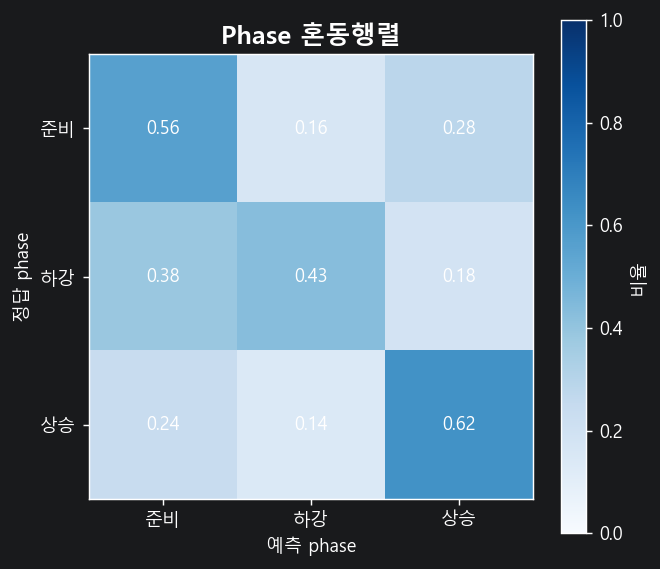

In [7]:
def read_phase_confusion_matrix(path, preferred_mode="offline_smooth"):
    """Read phase_confusion_matrix.csv produced by train_ablation diagnostics."""
    path = Path(path)
    df = pd.read_csv(path)
    pred_cols = [f"pred_{p}" for p in PHASE_NAMES]

    if set(pred_cols).issubset(df.columns):
        if "mode" in df.columns:
            modes = df["mode"].dropna().astype(str).unique().tolist()
            mode = preferred_mode if preferred_mode in modes else modes[0]
            df = df[df["mode"].astype(str) == mode]
        mat = df[pred_cols].head(3).to_numpy(dtype=float)
        return pd.DataFrame(mat, index=PHASE_NAMES, columns=PHASE_NAMES), path

    # Generic matrix format: first column is index, next 3 columns are ready/down/up.
    if set(PHASE_NAMES).issubset(df.columns):
        mat = df[PHASE_NAMES].head(3).to_numpy(dtype=float)
        return pd.DataFrame(mat, index=PHASE_NAMES, columns=PHASE_NAMES), path

    raise ValueError(f"Unsupported confusion matrix CSV format: {path}")


manual_phase_cm = pd.DataFrame(
    [
        [0.66, 0.20, 0.14],
        [0.15, 0.72, 0.13],
        [0.10, 0.13, 0.77],
    ],
    index=PHASE_NAMES,
    columns=PHASE_NAMES,
)

cm = None
cm_source = "manual_phase_cm"
for path in sorted((ROOT / "phase_experiments").rglob("phase_confusion_matrix.csv")):
    try:
        cm, used_path = read_phase_confusion_matrix(path)
        cm_source = str(used_path.relative_to(ROOT))
        break
    except Exception:
        continue

if cm is None:
    cm = manual_phase_cm.copy()
else:
    # Convert counts to row-normalized ratio if the matrix looks like counts.
    if cm.to_numpy().max() > 1.0:
        cm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0)

cm_plot = cm.rename(index=PHASE_KR, columns=PHASE_KR)
print("confusion matrix source:", cm_source)
display(cm_plot)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
if sns is not None:
    sns.heatmap(cm_plot, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True, cbar_kws={"label": K["ratio"]}, ax=ax)
else:
    im = ax.imshow(cm_plot.to_numpy(), cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label=K["ratio"])
    ax.set_xticks(range(len(cm_plot.columns)), cm_plot.columns)
    ax.set_yticks(range(len(cm_plot.index)), cm_plot.index)
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(j, i, f"{cm_plot.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title(K["phase_cm"], fontsize=14, weight="bold")
ax.set_xlabel(K["pred_phase"])
ax.set_ylabel(K["true_phase"])
savefig("05_phase_confusion_matrix.png")
plt.show()


## 6. Deadlift variability with val=2


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\06_deadlift_val2_variability.png


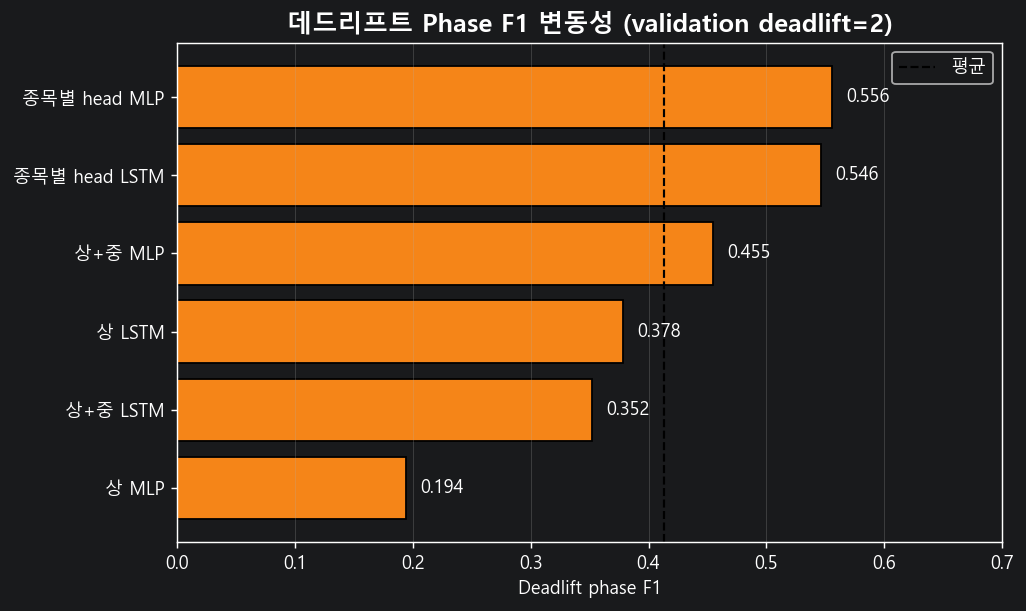

,config,deadlift_phase_f1,val_deadlift_videos
0,상 MLP,0.194,2
3,상+중 LSTM,0.352,2
1,상 LSTM,0.378,2
2,상+중 MLP,0.455,2
5,종목별 head LSTM,0.546,2
4,종목별 head MLP,0.556,2


In [8]:
fig, ax = plt.subplots(figsize=(8.0, 4.8))
plot_df = deadlift_variability.sort_values("deadlift_phase_f1")
ax.barh(plot_df["config"], plot_df["deadlift_phase_f1"], color="#F58518", edgecolor="black")
ax.set_xlim(0, 0.70)
ax.set_xlabel("Deadlift phase F1")
ax.set_title(K["dead_var"], fontsize=14, weight="bold")
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["deadlift_phase_f1"] + 0.012, i, f"{row['deadlift_phase_f1']:.3f}", va="center", fontsize=10)
ax.axvline(plot_df["deadlift_phase_f1"].mean(), color="black", linestyle="--", linewidth=1.2, label=K["mean"])
ax.legend(frameon=True)
ax.grid(axis="x", alpha=0.25)
savefig("06_deadlift_val2_variability.png")
plt.show()

display(plot_df)


## 7. User vs expert joint-angle trajectory

Default expert JSON: `infer/squat_15.json`. Default user JSON: `infer/squat_user1.json`.
If user JSON is missing, the code creates a demo trajectory only for checking the plot layout.


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\07_user_vs_expert_joint_angle.png


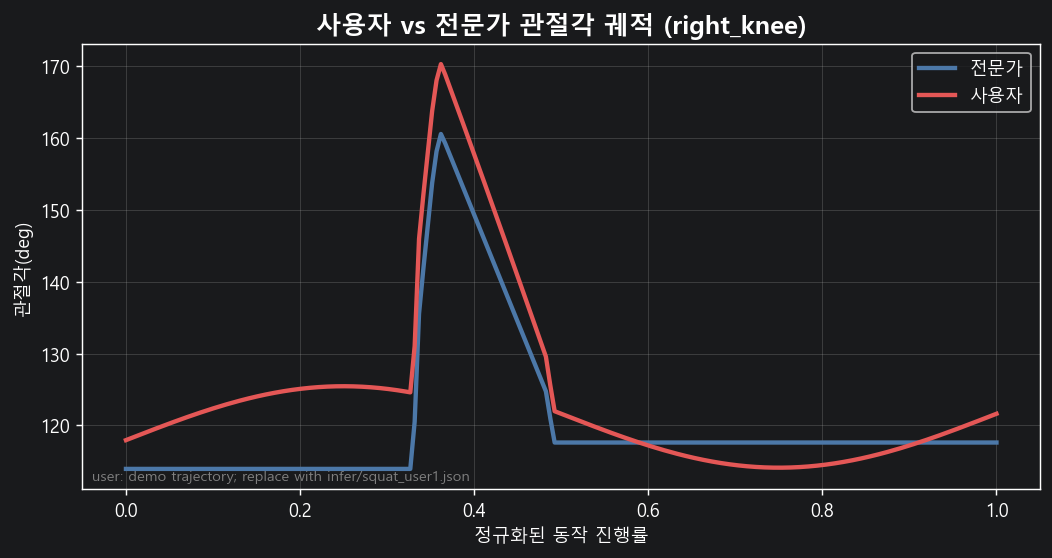

In [9]:
def landmark_xyz(lm):
    return np.asarray(lm[:3], dtype=float)


def joint_angle_deg(a, b, c):
    """Angle ABC in degrees."""
    a, b, c = landmark_xyz(a), landmark_xyz(b), landmark_xyz(c)
    v1, v2 = a - b, c - b
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom < 1e-9:
        return np.nan
    cosv = np.clip(np.dot(v1, v2) / denom, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosv)))


ANGLE_JOINTS = {
    "right_knee": (24, 26, 28),
    "left_knee": (23, 25, 27),
    "right_hip": (12, 24, 26),
    "left_hip": (11, 23, 25),
    "right_elbow": (12, 14, 16),
    "left_elbow": (11, 13, 15),
}


def angle_series_from_profile(profile, joint="right_knee", visibility_thr=0.25):
    a, b, c = ANGLE_JOINTS[joint]
    values = []
    for fr in profile["frames"]:
        lms = fr.get("landmarks", [])
        if max(a, b, c) >= len(lms):
            values.append(np.nan)
            continue
        if any(len(lms[idx]) >= 4 and lms[idx][3] < visibility_thr for idx in (a, b, c)):
            values.append(np.nan)
            continue
        values.append(joint_angle_deg(lms[a], lms[b], lms[c]))
    return pd.Series(values, dtype="float64").interpolate(limit_direction="both")


def resample_series(series, n=200):
    series = pd.Series(series, dtype="float64").interpolate(limit_direction="both")
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, n)
    return pd.Series(np.interp(x_new, x_old, series.to_numpy()), index=x_new)

USER_JSON = ROOT / "infer" / "squat_user1.json"
EXPERT_JSON = ROOT / "infer" / "squat_15.json"
ANGLE_JOINT = "right_knee"  # squat/deadlift: knee or hip, benchpress: elbow

expert_profile = load_profile_json(EXPERT_JSON)
expert_angle = resample_series(angle_series_from_profile(expert_profile, ANGLE_JOINT), n=200)

if USER_JSON.exists():
    user_profile = load_profile_json(USER_JSON)
    user_angle = resample_series(angle_series_from_profile(user_profile, ANGLE_JOINT), n=200)
    user_note = str(USER_JSON.relative_to(ROOT))
else:
    # Demo trajectory for layout check only. Replace USER_JSON with real extracted JSON for final analysis.
    user_angle = expert_angle + 7.5 * np.sin(np.linspace(0, 2 * np.pi, len(expert_angle))) + 4.0
    user_note = "demo trajectory; replace with infer/squat_user1.json"

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(expert_angle.index, expert_angle.values, label=K["expert"], linewidth=2.4, color="#4C78A8")
ax.plot(user_angle.index, user_angle.values, label=K["user"], linewidth=2.4, color="#E45756")
ax.set_title(f"{K['angle_traj']} ({ANGLE_JOINT})", fontsize=14, weight="bold")
ax.set_xlabel(K["progress"])
ax.set_ylabel(K["joint_angle"])
ax.grid(alpha=0.25)
ax.legend(frameon=True)
ax.text(0.01, 0.02, f"user: {user_note}", transform=ax.transAxes, fontsize=8, color="gray")
savefig("07_user_vs_expert_joint_angle.png")
plt.show()


## 8. Phase F1 by config table/bar


,config,subset,model,phase_f1
6,종목별 head MLP,상,MLP,0.729
7,종목별 head LSTM,상,LSTM,0.729
3,상 LSTM,상,LSTM,0.715
2,상 MLP,상,MLP,0.694
4,상+중 MLP,상+중,MLP,0.661
0,Full MediaPipe MLP,전체,MLP,0.654
5,상+중 LSTM,상+중,LSTM,0.645
1,YOLO MLP,전체,MLP,0.587


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\08_config_phase_f1_comparison.png


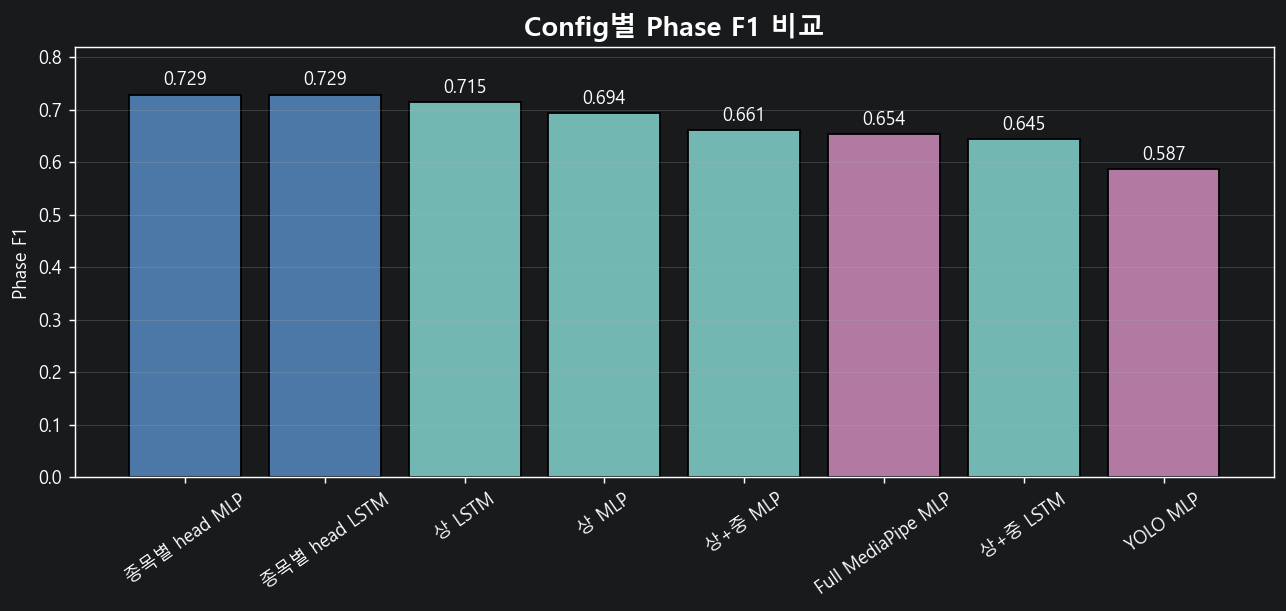

In [10]:
display(config_phase_f1.sort_values("phase_f1", ascending=False))

fig, ax = plt.subplots(figsize=(10.0, 4.8))
plot_df = config_phase_f1.sort_values("phase_f1", ascending=False)
colors = ["#4C78A8" if "head" in c else "#72B7B2" if K["high"] in c else "#B279A2" for c in plot_df["config"]]
ax.bar(plot_df["config"], plot_df["phase_f1"], color=colors, edgecolor="black")
ax.set_title(K["config_phase_f1"], fontsize=15, weight="bold")
ax.set_ylabel("Phase F1")
ax.set_ylim(0, 0.82)
ax.tick_params(axis="x", rotation=35)
annotate_bars(ax, fmt="{:.3f}", dy=0.012)
ax.grid(axis="y", alpha=0.25)
savefig("08_config_phase_f1_comparison.png")
plt.show()


## 9. Training/validation curves: loss and F1

The code chooses the first preferred `history.json` under `phase_experiments/`.


history source: phase_experiments\quality_high_per_exercise_head\20260617T072959Z\mediapipe_barbell_mediapipe33_barbell34_wrists_jall_lstm_h128_c16_pw_2.0_ts2_do03_aug1_l1_head_per_exercise_mlp_cond_ground_truth_exercise_label_label_bar_direction_edge_wrists_per_exercise_head\history.json
history keys: ['train_loss', 'val_action_acc', 'val_action_f1', 'val_phase_acc', 'val_phase_f1']


C:\Users\kojy1\AppData\Local\Temp\ipykernel_26752\1505094566.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\09_training_validation_curves.png


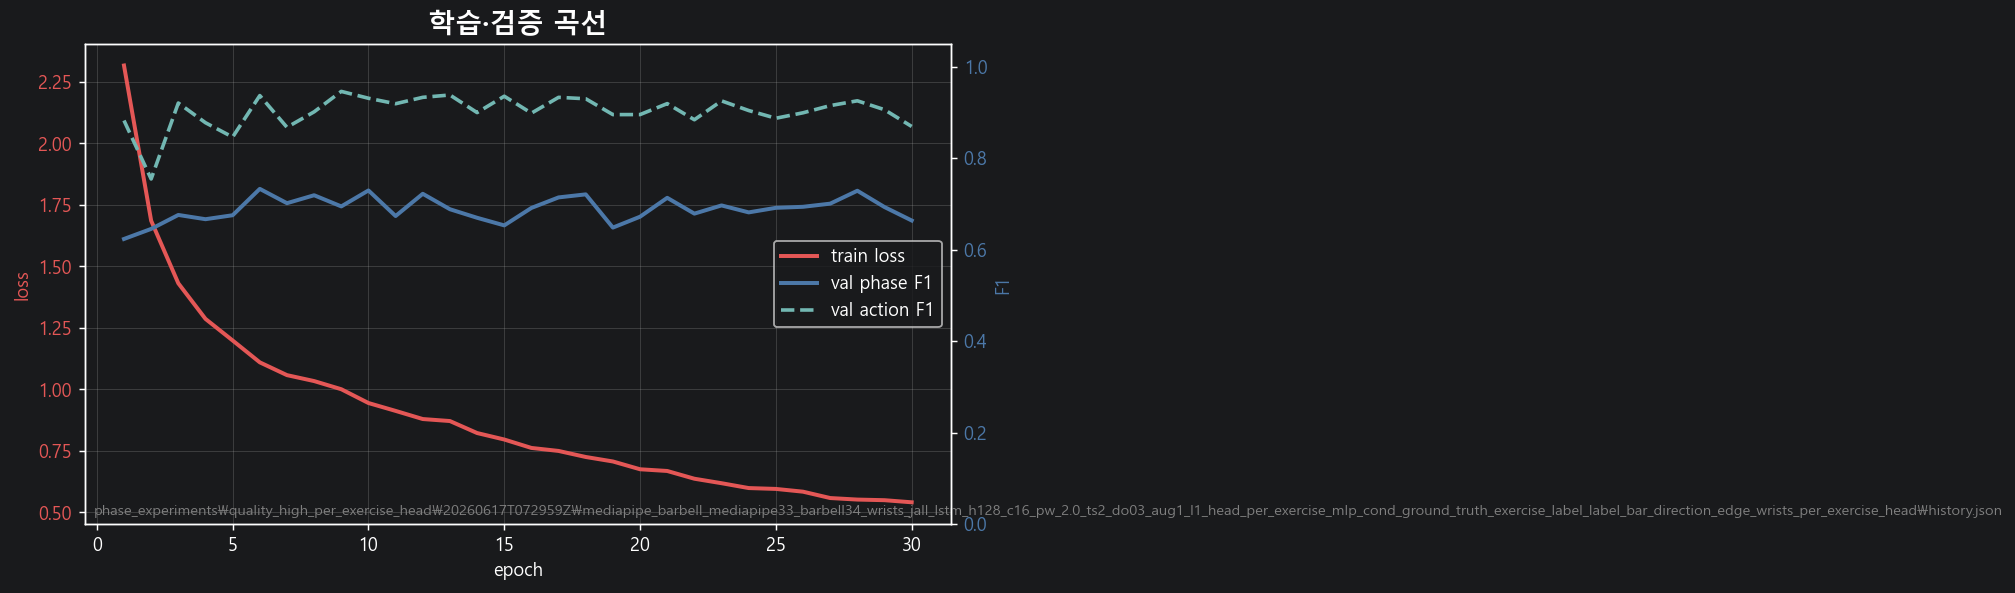

In [11]:
def find_history_json():
    preferred_roots = [
        ROOT / "phase_experiments" / "quality_high_per_exercise_head",
        ROOT / "phase_experiments" / "quality_filter_best_arch_lstm",
        ROOT / "phase_experiments" / "quality_filter",
        ROOT / "phase_experiments",
    ]
    seen = set()
    for root in preferred_roots:
        if not root.exists():
            continue
        for path in sorted(root.rglob("history.json")):
            if path in seen:
                continue
            seen.add(path)
            return path
    return None


def load_history(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)

history_path = find_history_json()
if history_path is None:
    raise FileNotFoundError("No history.json found under phase_experiments/")

history = load_history(history_path)
print("history source:", history_path.relative_to(ROOT))
print("history keys:", list(history.keys()))

epochs = np.arange(1, len(history.get("train_loss", [])) + 1)
if len(epochs) == 0:
    raise ValueError(f"history has no train_loss: {history_path}")

fig, ax1 = plt.subplots(figsize=(8.6, 4.8))
ax1.plot(epochs, history["train_loss"], label="train loss", color="#E45756", linewidth=2.2)
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss", color="#E45756")
ax1.tick_params(axis="y", labelcolor="#E45756")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
if "val_phase_f1" in history:
    ax2.plot(epochs, history["val_phase_f1"], label="val phase F1", color="#4C78A8", linewidth=2.2)
if "val_action_f1" in history:
    ax2.plot(epochs, history["val_action_f1"], label="val action F1", color="#72B7B2", linewidth=2.0, linestyle="--")
ax2.set_ylabel("F1", color="#4C78A8")
ax2.tick_params(axis="y", labelcolor="#4C78A8")
ax2.set_ylim(0, 1.05)

lines, labels = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    lines += h
    labels += l
ax1.legend(lines, labels, loc="center right", frameon=True)
ax1.set_title(K["train_val_curve"], fontsize=15, weight="bold")
ax1.text(0.01, 0.02, str(history_path.relative_to(ROOT)), transform=ax1.transAxes, fontsize=8, color="gray")

savefig("09_training_validation_curves.png")
plt.show()


## Regenerate

Run all cells. PNG outputs are written to `report_figures/`.
